## Introduction

Infographics, or a thoughtful visual representation of data and information, can be powerful tools to convey a message effectively. Appealing designs grab the viewer's attention, and the intuitive charts and graphs make the main message easy to understand and remember. 

There are many aspects that go into an infographic. Some elements, especially those pertaining to the graphs, can actually be done inside Python scripts. 



In this blog post, I explain how to incorporate [icons from Font Awesome](https://fontawesome.com/) into `matplotlib` figures as text and path objects. In general, [treating icons as text](#sec-icon-text) is simpler, and suffices when plotting only a couple icons. On the other hand, if you want to use the icons in scatter plots, it is advisable to [convert icons into paths](#sec-icon-path).

### What You'll Learn in this Tutorial

By the end of this short tutorial, you'll learn how to:

- **Draw Font Awesome icons as text objects** with `matplotlib.pyplot.text()` 
- **Convert Font Awesome icons to paths** for plotting with `matplotlib.pyplot.scatter()`
- **Make graphs with icons**
- **Apply an image overlay to icons** with clipping

If you prefer to skip the explanations and jump straight to the implementation, you can [download the code from my GitHub repository](https://github.com/DataDrivenMai/DataDrivenMai-blog/tree/main/plotting-icons/). 

Here is the list of things you'll need to run the code.

### Prerequisites

- A copy of either the `plotting-icons.ipynb` Jupyter notebook or `plotting-icons.py` Python script from my [GitHub repository](https://github.com/DataDrivenMai/DataDrivenMai-blog/tree/main/plotting-icons)
- Python libraries
    - `matplotlib`

### Jargon

**Unicode**: An international standard for character and emoji encoding. It allows screens to display characters whether it be written in English, French, Japanese or Hebrew. 

**Path**: The `matplotlib.path` objects, or similar `matplotlib.textpath` objects.

**Bounding box**: 

**Clipping**: 

## Download the Font Awesome Package for Desktop

There are several methods to make the Font Awesome icons usable in the Python environment. I find [downloading Font Awesome package for desktop](https://fontawesome.com/download) to the `data\` subdirectory to be quick and intuitive. If you download the free package like I did, you should end up with three OTF files with `'Brands-Regular'`, `'Free-Regular'` and `'Free-Solid'` in the file names.

At the time of writing this blog (May 2026), the Font Awesome package is version 7.2.0, as indicated by `'Font Awesome 7'` in the three extracted OTF files. If you are downloading after a version update, the file names will differ from the ones I've provided below.


In [1]:
# Path to your downloaded Font Awesome OTF file
font_path_brands = "./data/Font Awesome 7 Brands-Regular-400.otf"
font_path_regular = "./data/Font Awesome 7 Free-Regular-400.otf"
font_path_solid = "./data/Font Awesome 7 Free-Solid-900.otf"

We also need the `matplotlib.font_manager.FontProperties` class to store information about each Font Awesome icon groups.

In [2]:
# Import matplotlib.font_manager
import matplotlib.font_manager as fm

Store the font properties of each OTF file for use when displaying the icons. 

In [3]:
# Create FontProperties objects for each of the Font Awesome OTF files
fp_brands = fm.FontProperties(fname=font_path_brands)
fp_regular = fm.FontProperties(fname=font_path_regular)
fp_solid = fm.FontProperties(fname=font_path_solid)

We can now choose the icon we'd like to use in our Python projects. 

## Find the Unicode of Your Chosen Icons

To use Font Awesome icons in your Python projects, you will need to know the icon's

- Unicode identifier
- Font package that it belongs to

Both can be found on the Font Awesome website. 

For example, Font Awesome's lightbulb icon has two variants: the [regular lightbulb design](https://fontawesome.com/icons/classic/regular/lightbulb) and the [solid lightbulb design](https://fontawesome.com/icons/classic/solid/lightbulb). The Unicode identifier can be found in the top right corner (as indicated by the blue box in @fig-lightbulbs), while the Font Awesome font package can be found within the HTML class (as shown by the orange box in @fig-lightbulbs), or within the HTML address of the icon. You'll notice that the lightbulb icon variants have the same Unicode identifier of f0eb, but belong to different font packages.

::: {#fig-lightbulbs layout-ncol=2}

![Regular lightbulb icon](./images/lightbulb-regular.png){#fig-lightbulb-regular}

![Solid lightbulb icon](./images/lightbulb-solid.png){#fig-lightbulb-solid}

Unicode identifier (top right blue box) and font package (orange box) for two lightbulb icon variants in Font Awesome
:::

To use the icons in Python, we will be be using the escape sequence of `'\u'` to indicate that the item we are dealing with is a Unicode identifier. In the case of the regular lightbulb icon, the Python code will be `'\uf0eb'`.

The chosen icons can now be used as text objects. 

## Drawing Icons on Plots as Text{#sec-icon-text}

In the previous section, we saw that [icons from Font Awesome](https://fontawesome.com/) are treated as characters, each with its own unique [Unicode identifier](https://home.unicode.org/). As such, the simplest method of drawing icons on a plot are to treat them as text objects, specified by their Unicode.

Let's make a simple dictionary containing five icons from the Font Awesome brands package to call each Unicode using a key. Remember to include the `'\u'` Unicode escape sequence.

In [4]:
# Dictionary of five Font Awesome brand icons
fa_dict = {
    "google": "\uf1a0",
	"apple": "\uf179",
	"meta": "\ue49b",
	"amazon": "\uf270",
	"microsoft": "\uf17a"
}

We'll need the `matplotlib.pyplot` library to make the figures to plot the text upon.

In [5]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

The icons can now be placed in a figure using `plt.text()`. 

### Designate the Location, Size and Color of Icons

Below are the minimal parameters required to draw the icons using `plt.text()` function: 

- x coordinate
- y coordinate
- Unicode identifier
- Appropriate font properties

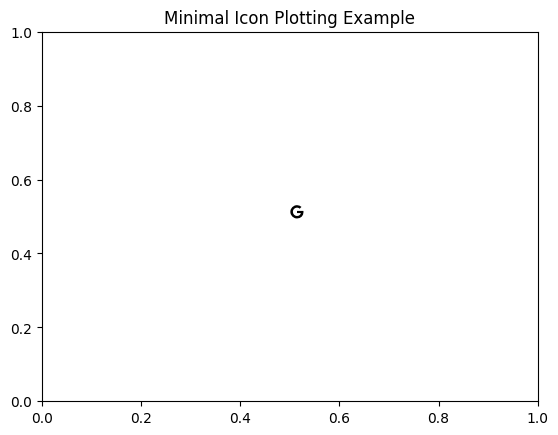

In [6]:
# Make a figure with minimal parameters for icon placement
plt.figure()

# Place the Google icon at the center of the plot using the brands font
plt.text(0.5, 0.5, fa_dict["google"], fontproperties=fp_brands)

# Plot logistics
plt.title("Minimal Icon Plotting Example")
plt.show()

A small black icon shows up at the designated location. The default display is rather small, so we'll start by modifying its size in the next section.

### Change Size of Icons as Texts

The size of the icons can be changed like any text object using the `fontsize` parameter within the `plt.text()` function. A specific point size as a floating value can be used. Alternatively, the user can designate a relative size such as `'x-small'`. We'll see how this looks:

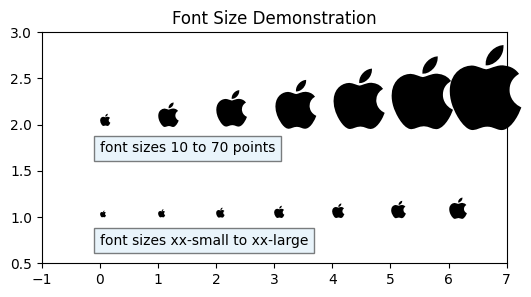

In [7]:
# Relative icon sizes
font_sizes1 = ['xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large']
font_sizes2 = [10, 20, 30, 40, 50, 60, 70]

# Make a figure to demonstrate the different font sizes
plt.figure(figsize=(6, 3))

# Plot the relative and absolute font sizes
for i in range(len(font_sizes1)):
	plt.text(i, 1, fa_dict["apple"], fontproperties=fp_brands, fontsize=font_sizes1[i])
	plt.text(i, 2, fa_dict["apple"], fontproperties=fp_brands, fontsize=font_sizes2[i])

# Description
plt.text(0, 0.7, "font sizes xx-small to xx-large", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0, 1.7, "font sizes 10 to 70 points", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.xlim(-1, len(font_sizes1))
plt.ylim(0.5, 3.0)
plt.title("Font Size Demonstration")
plt.show()

To make icons visibly large, you'll most likely designate a point value for its `fontsize` parameter, rather than use the relative sizes. 

Next, let's try changing the color of the icons.

### Change Color of Icons as Texts

To change icon colors, simply specify the desired `color` parameter in `plt.text()` function. There are three useful ways to designate the icon colors.

1. Use named colors like `'red'` or `'blue'`
2. Specify a color hex codes like `'#22668D'`
3. Use color gradients such as the ones available with `plt.colormaps`

A demonstration of the three methods are shown:

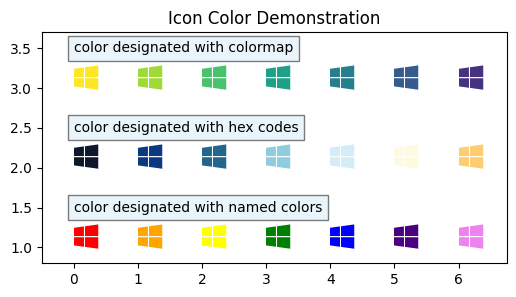

In [8]:
# Three types of color specifications
font_colors1 = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'violet']
font_colors2 = ['#0F172A', '#0A3981', '#22668D', '#8ECDDD', '#D4EBF8', '#FFFADD', '#FFCC70']
font_colors3 = plt.colormaps['viridis_r']
icon_size = 20

# Make a figure to demonstrate the different icon colors
plt.figure(figsize=(6, 3))

# Plot the relative and absolute font sizes
for i in range(len(font_colors1)):
	plt.text(i, 1, fa_dict["microsoft"], fontproperties=fp_brands, fontsize=icon_size, color=font_colors1[i])
	plt.text(i, 2, fa_dict["microsoft"], fontproperties=fp_brands, fontsize=icon_size, color=font_colors2[i])
	plt.text(i, 3, fa_dict["microsoft"], fontproperties=fp_brands, fontsize=icon_size, color=font_colors3(i/len(font_colors1)))

# Description
plt.text(0, 1.45, "color designated with named colors", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0, 2.45, "color designated with hex codes", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0, 3.45, "color designated with colormap", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.xlim(-0.5, len(font_colors1)-0.25)
plt.ylim(0.8, 3.7)
plt.title("Icon Color Demonstration")
plt.show()

We can change the icon size and color. Next we'll see how to adjust its rotation.

### Change Rotation Angle of Icons as Texts

Rotating icons as text objects is as easy as setting a degrees value to the `rotation` parameter in `plt.text()`. Positive values rotate the icon counter-clockwise

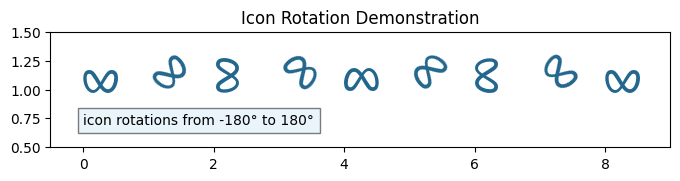

In [ ]:
# Icon rotation angles
icon_rotation = [-180, -135, -90, -45, 0, 45, 90, 135, 180]

# Other parameters of the icon
icon_size = 20
icon_color = '#22668D'

# Make a figure to demonstrate the different font sizes
plt.figure(figsize=(8, 1.5))

# Plot the relative and absolute font sizes
for i in range(len(icon_rotation)):
	plt.text(i, 1, fa_dict["meta"], fontproperties=fp_brands, fontsize=icon_size, color=icon_color, rotation=icon_rotation[i])
	
# Description
plt.text(0, 0.7, f"icon rotations from {icon_rotation[0]}° to {icon_rotation[-1]}°", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.xlim(-0.5, len(icon_rotation))
plt.ylim(0.5, 1.5)
plt.title("Icon Rotation Demonstration")
plt.show()

We can now designate the icon size, color and rotation. We will now look into the details of its placement location of text objects.

### Horizontal and Vertical Alignment of Texts{#sec-ha-va-text}

Knowing how to draw icons at a designated location with a specific size and color meets most user's needs. Add onto that the power to rotate the icon, and you are already well equipped for most tasks. However, knowing how the icons are placed on the plot allows you to be even more specific in its alignment and placement. 

Let's start by plotting various brand icons with different sizes, colors and rotation values. We will also identify the exact coordinates where each icon was placed to see the alignment of text objects relative to the user-specified coordinates.

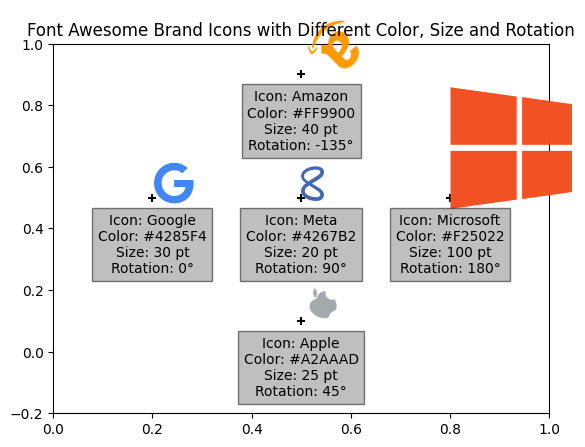

In [10]:
# Designate the icons to plot
icons = ["google", "apple", "meta", "amazon", "microsoft"]

# Designate the locations for each icon
xLoc = [0.2, 0.5, 0.5, 0.5, 0.8]
yLoc = [0.5, 0.1, 0.5, 0.9, 0.5]

# Specify color, size and rotation for each icon
icon_colors = ['#4285F4', '#A2AAAD', '#4267B2', '#FF9900', '#F25022']
font_sizes = [30, 25, 20, 40, 100]
icon_rotation = [0, 45, 90, -135, 180]

#| label: fig-gafam
#| fig-cap: "Google, Apple, Meta, Amazon and Microsoft icons plotted with different colors, sizes and rotations."

# Plot the figure with all the icons, colors, sizes and rotations
plt.figure()

for i in range(len(icons)):
    plt.text(xLoc[i], yLoc[i], fa_dict[icons[i]], fontproperties=fp_brands, color=icon_colors[i], fontsize=font_sizes[i], rotation=icon_rotation[i])
    
	# Scatter plot of icon locations
    plt.scatter(xLoc[i], yLoc[i], color='black', marker='+')

	# Description
    describe_now = f"Icon: {icons[i].capitalize()}\nColor: {icon_colors[i]}\nSize: {font_sizes[i]} pt\nRotation: {icon_rotation[i]}°"
    plt.text(xLoc[i], yLoc[i] - 0.05, describe_now, fontsize=10, ha='center', va='top', bbox=dict(facecolor='gray', alpha=0.5))

# Set the details of the plot before showing
plt.title("Font Awesome Brand Icons with Different Color, Size and Rotation")
plt.xlim(0, 1)
plt.ylim(-0.2, 1)
plt.show()

The coordinates where each icon was placed are indicated with a small black '+'. We see that the default is to align the lower left corner of the icons to the user specified coordinates. 

Vertical and horizontal alignment of text objects relative to the designated coordinates can be adjusted by specifying the `'va'` (vertical alignment) and `'ha'` (horizontal alignment) parameters. There are five options for vertical alignment: `'baseline', 'bottom', 'center', 'center_baseline', 'top'` and three possible options for horizontal alignment: `'left', 'center', 'right'`. 

The code below demonstrates how these different options show up on the plot. 

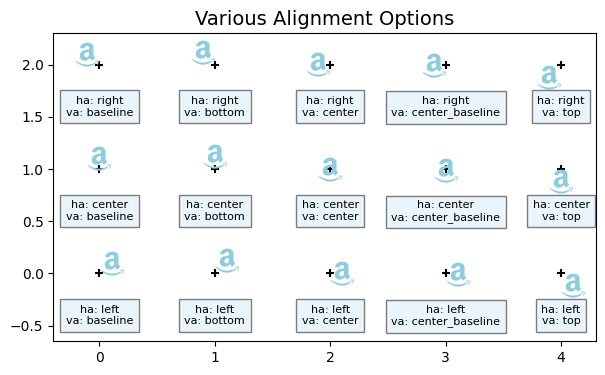

In [14]:
# Various vertical and horizontal alignments to test
icon_va = ['baseline', 'bottom', 'center', 'center_baseline', 'top']
icon_ha = ['left', 'center', 'right']

# Other variables
icon_color = '#8ECDDD'

#| label: fig-alignment
#| fig-cap: "Fifteen different combinations of horizontal and vertical alignments."

# Create figure
plt.figure(figsize=(7, 4))

# Plot the icons with different horizontal and vertical alignments
for i in range(len(icon_va)):
	for j in range(len(icon_ha)):
		plt.text(i, j, fa_dict["amazon"], fontproperties=fp_brands, fontsize=20, color=icon_color, ha=icon_ha[j], va=icon_va[i])
		plt.text(i, j - 0.3, f'ha: {icon_ha[j]}\nva: {icon_va[i]}', fontsize=8, ha='center', va='top', bbox=dict(facecolor='#D4EBF8', alpha=0.5))
		plt.scatter(i, j, color='black', marker='+')

# Plot logistics
plt.xlim(-0.4, len(icon_va)-0.7)
plt.ylim(-0.65, len(icon_ha)-0.7)
plt.title("Various Alignment Options", fontsize=14)
plt.show()

Some of the vertical alignment options are quite similar. For example `'baseline'` is only slightly higher than `'bottom'`, and `'center_baseline'` looks to be a tiny bit higher than `'center'`. Perhaps the change may be more noticeable if you are working with larger icon sizes. 

Refer to the [`matplotlib` documentation on `pyplot.text()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.text.html) for information on how to further customize icons as text.

Plotting icons as text objects is quite simple and will be sufficient for most users. However, it has its quirks. For example, you may notice in @fig-gafam that text objects are always placed on top of scatter plot markers, regardless of the placement order. Additionally, text objects can overflow over the axis limits. If you want to contain teh icons within the axis limits, converting them as paths and scatter plotting them may be a better option.

## Drawing Icons on Plots as Paths{#sec-icon-path}

Converting Font Awesome icons into path objects allow us greater flexibility. We can use them as markers for scatter plots, which automatically keeps them within the axis limits, allows the user to specify different marker edge and face colors, or apply an image overlay to it. We can even designate a bounding box to effectively show a fraction of an icon. An added benefit is that, once a path is created from the icon, we no longer need to remember the font properties for plotting them.

But to change things up, we'll add a couple new entries into the dictionary.

In [15]:
# Add a couple new entries to the dictionary
fa_dict.update({"church": '\uf51d', 
                "circle": '\uf111', 
                "fire": '\uf7e4',
                "moon": '\uf186', 
                "mound": '\ue52d', 
                "spiral": '\ue80a', 
                "star": '\uf005', 
                "water": '\uf773'})

### Convert Icons to Paths

As explained before, Font Awesome icons are treated like fancy text objects. To convert these into paths, we'll use the TextPath class from `matplotlib.text`. Refer to the [`matplotlib` documentation on `text.TextPath`](https://matplotlib.org/3.5.3/api/textpath_api.html) if you are interested in the details.


In [16]:
# Import the TextPath class from matplotlib.text
import matplotlib.text as mtext

To convert a Font Awesome icon from a text to a path using `matplotlib.text.TextPath()`, we require the following:

- Offset position of the text
- Unicode identifier
- Font properties

Let's create two variants of the star icon with `mtext.TextPath()`:

In [17]:
# Convert the two variants of the star icon to TextPath object
star_reg_path = mtext.TextPath((0, 0), fa_dict["star"], prop=fp_regular)
star_solid_path = mtext.TextPath((0, 0), fa_dict["star"], prop=fp_solid)

### Change Marker Size and Color in Scatter Plots

The generated path can be used as a marker in the `plt.scatter()` function. Aside from the coordinates of the scatter plot, the marker size and color can be specified with `s` and `color` parameters.

Below is a demonstration of `plt.scatter()` using the paths generated above for the `marker` parameter. The marker size is specified with the `marker_size` list. The marker color is specified with three different methods as before: 

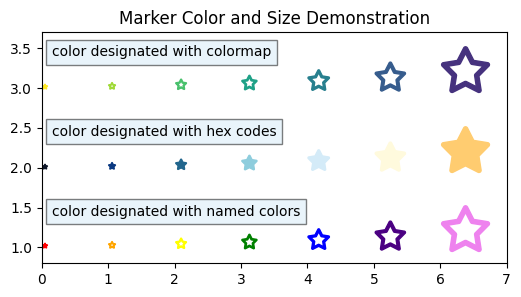

In [53]:
# Modify marker size and color
marker_size = [50, 100, 250, 500, 1000, 2000, 5000]
icon_colors1 = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'violet']
icon_colors2 = ['#0F172A', '#0A3981', '#22668D', '#8ECDDD', '#D4EBF8', '#FFFADD', '#FFCC70']
icon_colors3 = plt.colormaps['viridis_r']

# Generate a figure
plt.figure(figsize=(6, 3))

# Generate the stars with the plt.scatter function
for i in range(0, len(marker_size)):
	plt.scatter(i, 1, color=icon_colors1[i], marker=star_reg_path, s=marker_size[i])
	plt.scatter(i, 2, color=icon_colors2[i], marker=star_solid_path, s=marker_size[i])
	plt.scatter(i, 3, color=icon_colors3(i/len(marker_size)), marker=star_reg_path, s=marker_size[i])

# Description
plt.text(0.15, 1.4, "color designated with named colors", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0.15, 2.4, "color designated with hex codes", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0.15, 3.4, "color designated with colormap", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.xlim(0, len(marker_size))
plt.ylim(0.8, 3.7)
plt.title("Marker Color and Size Demonstration")
plt.show()

But that's not all the color options available. With `plt.scatter()`, we can specify different colors for the marker face and the marker edge. 

### Different Edge and Face Colors

We specified the marker color with the `color` parameter in `plt.scatter()`. We can further specify the marker `edgecolor` with `'face'`, which gives the same edge color as the marker face; `'none'`, which removes the edge line altogether' or specify a specific edge color. 

In the example below, we show the three `edgecolor` options on the solid star icon. The `linewidth` parameter has been set to 5 to make the differences more noticeable between the `'none'` option and the others.

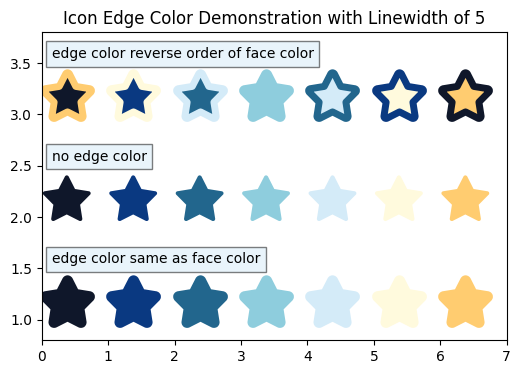

In [106]:
# Modify size and color
marker_size = 5000
icon_colors = ['#0F172A', '#0A3981', '#22668D', '#8ECDDD', '#D4EBF8', '#FFFADD', '#FFCC70']
edge_width = 5

# Generate a figure
plt.figure(figsize=(6, 4))

# Generate the stars with the plt.scatter function
for i in range(0, len(icon_colors)):
	plt.scatter(i, 1, color=icon_colors[i], marker=star_solid_path, s=marker_size, edgecolor='face', linewidth=edge_width)
	plt.scatter(i, 2, color=icon_colors[i], marker=star_solid_path, s=marker_size, edgecolor='none', linewidth=edge_width)
	plt.scatter(i, 3, color=icon_colors[i], marker=star_solid_path, s=marker_size, edgecolor=icon_colors[len(icon_colors)-i-1], linewidth=edge_width)

# Description
plt.text(0.15, 1.55, "edge color same as face color", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0.15, 2.55, "no edge color", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0.15, 3.55, "edge color reverse order of face color", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.title(f"Icon Edge Color Demonstration with Linewidth of {edge_width}")
plt.xlim(0, len(icon_colors))
plt.ylim(0.8, 3.8)
plt.show()

As seen in the middle row, setting `edgecolor='none'` keeps the icons sharp-looking at the star points. Specifying `edgecolor='face'` can give a rounded impression to the icons. Designating a black or dark edgecolor can make icons with pale colors stand out. 

We can now designate the position of the icon as a marker, its color (`'color'` parameter), and its size (`'s'` parameter). The creative flexibility of `edgecolor` and `linewidth` are features of `plt.scatter()` function that were not available with the text options. 

However, when it comes to rotating markers, `plt.scatter()` does not have this functionality. But do not fret; there is a workaround. We can create a path with a preset rotation angle, and plot that.

### Rotate Paths to Rotate Markers

To rotate paths, we need the `matplotlib.transforms` module:

In [107]:
# Import matplotlib.transforms to use Affine_2D
import matplotlib.transforms as mtransforms

We can use the `mtransforms.Affine2D().rotate_deg()` to create a rotation type of transformation, then apply this to the original path using `path_name.transformed(transform_type)`. 

The result of markers rotation with `mtransforms.Affine2D().rotate_deg()` are shown below:

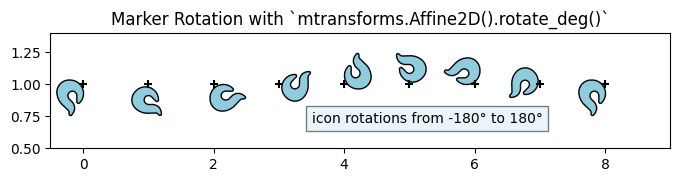

In [109]:
# Generate a default path with no rotation
fire_path_default = mtext.TextPath((0, 0), fa_dict["fire"], prop=fp_solid)

# Marker rotation angles
icon_rotation = [-180, -135, -90, -45, 0, 45, 90, 135, 180]

# Other icon parameters
icon_size = 2000
icon_color = '#8ECDDD'
edge_color = 'black'

# Make a figure to demonstrate the different font sizes
plt.figure(figsize=(8, 1.5))

# Plot the relative and absolute font sizes
for i in range(len(icon_rotation)):
	# Generate a path with rotation using mtransforms.Affine2D().rotate_deg()
	rot_transform = mtransforms.Affine2D().rotate_deg(icon_rotation[i])
	fire_path_rot = fire_path_default.transformed(rot_transform)
		
	# Scatter plot of icon and a '+' to mark the spot
	plt.scatter(i, 1, color=icon_color, marker=fire_path_rot, s=icon_size, edgecolors=edge_color)
	plt.scatter(i, 1, color='black', marker='+')
	
# Description
plt.text(3.5, 0.7, f"icon rotations from {icon_rotation[0]}° to {icon_rotation[-1]}°", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.xlim(-0.5, len(icon_rotation))
plt.ylim(0.5, 1.4)
plt.title("Marker Rotation with `mtransforms.Affine2D().rotate_deg()`")
plt.show()

The paths are rotated around the (0, 0) position marked by the '+'. This affects the alignment and positioning of the marker. 

Alternatively, the path can be rotated "on the spot" using `mtransforms.Affine2D().rotate_deg_around()`. The function will need the center point of the icon to stay put. 

Let's see how this would look like:

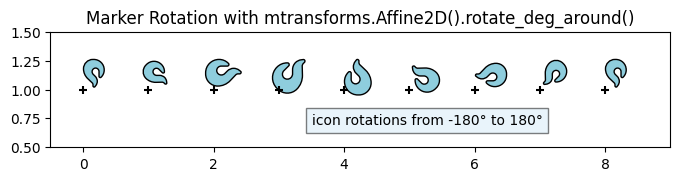

In [110]:
# Generate a default path with no rotation
fire_path_default = mtext.TextPath((0, 0), fa_dict["fire"], prop=fp_solid)

# Marker rotation angles
icon_rotation = [-180, -135, -90, -45, 0, 45, 90, 135, 180]

# Other icon parameters
icon_size = 2000
icon_color = '#8ECDDD'
edge_color = 'black'

# Make a figure to demonstrate the different font sizes
plt.figure(figsize=(8, 1.5))

# Plot the relative and absolute font sizes
for i in range(len(icon_rotation)):
	# Calculate the middle point
	max_x, max_y = fire_path_default.vertices.max(axis=0)
	min_x, min_y = fire_path_default.vertices.min(axis=0)
	mid_x = (max_x - min_x) / 2
	mid_y = (max_y - min_y) / 2

	# Generate a path with rotation using mtransforms.Affine2D().rotate_deg_around()
	rot_transform_around = mtransforms.Affine2D().rotate_deg_around(mid_x, mid_y, icon_rotation[i])
	fire_path_rot = fire_path_default.transformed(rot_transform_around)
	
	# Scatter plot of icon and a '+' to mark the spot
	plt.scatter(i, 1, color=icon_color, marker=fire_path_rot, s=icon_size, edgecolors=edge_color)
	plt.scatter(i, 1, color='black', marker='+')
	
# Description
plt.text(3.5, 0.7, f"icon rotations from {icon_rotation[0]}° to {icon_rotation[-1]}°", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.xlim(-0.5, len(icon_rotation))
plt.ylim(0.5, 1.5)
plt.title("Marker Rotation with mtransforms.Affine2D().rotate_deg_around()")
plt.show()

We can see the icon has been successfully rotated on the spot, with the placement marker remaining on the lower left corner of the marker. 

In the next section, we will work on modifying the position of this placement marker. 

### Greater Precision in Horizontal and Vertical Alignment

We saw that [text objects have various horizontal vertical alignment options](#sec-ha-va-text). @fig-alignment showed fifteen different alignment options available with text objects. 

Alignment options are not available in the `plt.scatter()` function, but can be specified in the creation of the path objects with `text.TextPath` class. By specifying x and y coordinate offsets and a `size` argument, we can designate how icons will be placed with the `plt.scatter()` function.

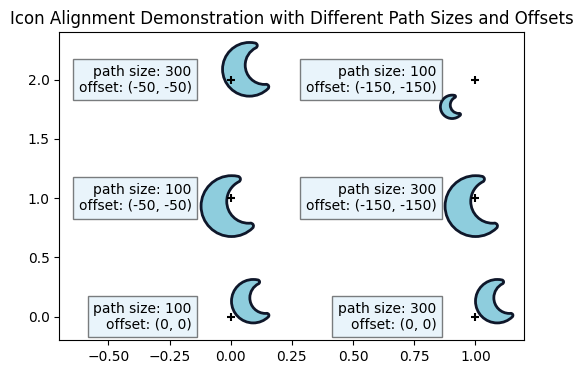

In [112]:
# Make several moon icons with different size and offset coordinates 
offset_xy = [[(0, 0), (0, 0)], 
             [(-50, -50), (-150, -150)], 
             [(-50, -50), (-150, -150)]] 
path_size = [[100, 300], 
             [100, 300], 
             [300, 100]]

# Modify size and color
marker_size = 3000
icon_faceCol = '#8ECDDD'
icon_edgeCol = '#0F172A'
edge_width = 2

# Generate a figure
plt.figure(figsize=(6, 4))

# Generate the stars with the plt.scatter function
for i in range(0, len(offset_xy)):
	for j in range(0, len(offset_xy[0])):
		# Make path with user-specified size and offset_xy
		moon_path_align = mtext.TextPath(offset_xy[i][j], fa_dict["moon"], prop=fp_solid, size=path_size[i][j])

		# Scatter plot
		plt.scatter(j, i, color=icon_faceCol, marker=moon_path_align, s=marker_size, edgecolor=icon_edgeCol, linewidth=edge_width)
		plt.scatter(j, i, color='black', marker='+')
		
		# Description
		plt.text(j-0.16, i, f"path size: {path_size[i][j]}\noffset: {offset_xy[i][j]}", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5), ha='right', va='center')

# Plot logistics
plt.title("Icon Alignment Demonstration with Different Path Sizes and Offsets")
plt.xlim(-0.7, 1.2)
plt.ylim(-0.2, 2.4)
plt.show()

The marker `'s'` parameter in `plt.scatter()` is the biggest factor determining final icon size. In that regard, the size specified during path generation does not seem to affect the plotted marker as much. However, the path size interacts with the offset values, affecting how they are drawn in the final plot. 

For example, as seen in the bottom row of @fig-fifteen-align, an offset of `(0, 0)` makes identical markers regardless of the size used in the path generation. @fig-fifteen-align shows how specifying a negative offset of of `(-50, -50)` for the path size of `100` creates a path identical to a path with three times its size and offset (size of `300` and a negative offset of `(-150, 150)`). The top row shows the paths generated with the same offset as the middle row, but different path sizes. 

Below, we create nine icons with the same path size, but different offsets.

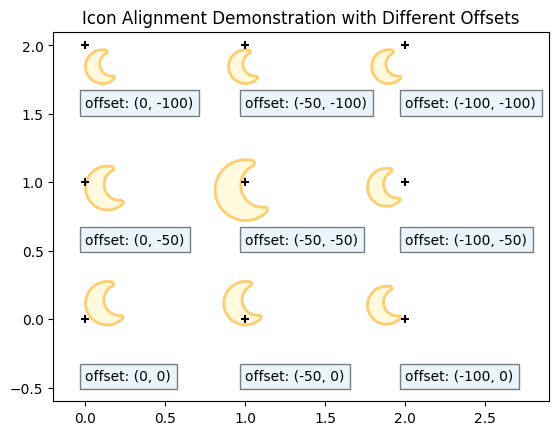

In [113]:
# User specified marker size and alignment
offset_xy2 = [[(0, 0), (-50, 0), (-100, 0)], 
			  [(0, -50), (-50, -50), (-100, -50)], 
			  [(0, -100), (-50, -100), (-100, -100)]]
path_size2 = 100

# Modify size and color
marker_size = 3000
icon_faceCol = '#FFFADD'
icon_edgeCol = '#FFCC70'
edge_width = 2

#| label: fig-fifteen-align
#| fig-cap: "Fifteen icon alignments possible with the plt.text() function"

# Generate a figure
plt.figure()

# Generate the stars with the plt.scatter function
for i in range(0, len(offset_xy2)):
	for j in range(0, len(offset_xy2[0])):
		# Generate a path with the user defined size and alignment
		moon_path_align = mtext.TextPath(offset_xy2[i][j], fa_dict["moon"], prop=fp_solid, size=path_size2)
		
		# Scatter plot
		plt.scatter(j, i, color=icon_faceCol, marker=moon_path_align, s=marker_size, edgecolor=icon_edgeCol, linewidth=edge_width)
		plt.scatter(j, i, color='black', marker='+')
		
		# Description
		plt.text(j, i-0.45, f"offset: {offset_xy2[i][j]}", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.title("Icon Alignment Demonstration with Different Offsets")
plt.xlim(-0.2, 2.9)
plt.ylim(-0.6, 2.1)
plt.show()

You may notice that an offset with half the magnitude of the path size doesn't seem to hit the center of the icon. This is most likely because the `mtext.TextPath` object does not fill the maximum available size area. 

I've provide a function, `CreateAlignedIcon()` that can adjust the placement coordinates precisely to the center of the icon. This function will require the `matplotlib.text`, `matplotlib.path` and `numpy` modules to run.

In [87]:
# Import modules 
import matplotlib.path as mpath
import numpy as np

In [88]:
def CreateAlignedIcon(icon_unicode, icon_font_prop, h_align, v_align):
    """Function to generate a path from the icon unicode with specified horizontal and vertical alignments. Requires matplotlib.path (as mpath), matplotlib.text (as mtext) and numpy (as np) to be imported.
    AUTHOR:     Mai Tanaka (www.DataDrivenMai.com)
    DATE:       2026-05-11
    REQUIRES:   icon_unicode = unicode for the icon (eg. '\uf005' for the star icon in Font Awesome)
                icon_font_prop = matplotlib.font_manager.FontProperties object for the icon 
                h_align = horizontal alignment (0 = left, 0.5 = center, 1 = right)
                v_align = vertical alignment (0 = bottom, 0.5 = center, 1 = top)
    RETURNS:    final_path = a matplotlib.path.Path object with the specified alignments
    """
    
	# Constants
    path_size = 100 # Arbitrary path size that is easy to work with

	# Create the initial TextPath to check its max and min values
    test_path = mtext.TextPath((0, 0), icon_unicode, prop=icon_font_prop, size=path_size)

	# Extract the vertices and codes from the test_path
    test_vertices = test_path.vertices
    test_codes = test_path.codes

	# Calculate the max and min coordinates of the icon path
    max_x, max_y = test_path.vertices.max(axis=0)
    min_x, min_y = test_path.vertices.min(axis=0)

	# Calculate the correctional offset required to obtain the desired alignment
    offset_x = (max_x - min_x) * h_align
    offset_y = (max_y - min_y) * v_align

	# Calculate the new vertices by applying the offsets
    new_vertices = np.zeros_like(test_vertices)
    new_vertices[:, 0] = test_vertices[:, 0] - min_x - offset_x
    new_vertices[:, 1] = test_vertices[:, 1] - min_y - offset_y

	# Create the final path with the new vertices and original code
    final_path = mpath.Path(new_vertices, test_codes)

	# Return English wind direction
    return final_path

Let's try drawing a scatter plot with icon paths generated with this new function:

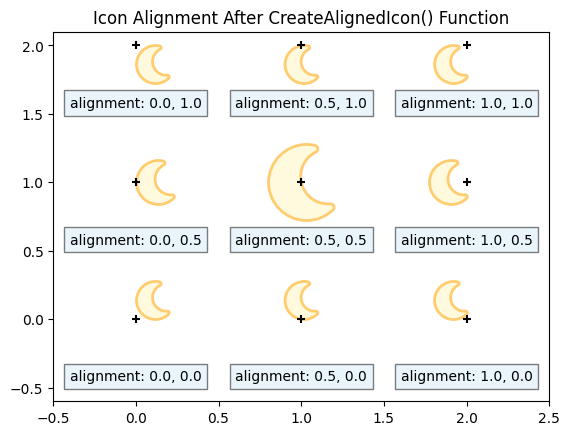

In [ ]:
# List of horizontal and vertical alignments to test
icon_halign = [[0.0, 0.5, 1.0], 
			   [0.0, 0.5, 1.0],
			   [0.0, 0.5, 1.0]]
icon_valign = [[0.0, 0.0, 0.0], 
			   [0.5, 0.5, 0.5],
			   [1.0, 1.0, 1.0]]

# Specify size and color for the icons
marker_size = 3000
icon_faceCol = '#FFFADD'
icon_edgeCol = '#FFCC70'
edge_width = 2

# Generate a figure
plt.figure()

# Generate the stars with the plt.scatter function
for i in range(0, len(icon_halign)):
	for j in range(0, len(icon_halign[0])):
		# Generate the icon with the CreateAlignedIcon function and plot it with plt.scatter
		icon_path = CreateAlignedIcon(fa_dict["moon"], fp_solid, icon_halign[i][j], icon_valign[i][j])

		# Scatter plot of the icon and a '+' to mark the spot
		plt.scatter(j, i, color=icon_faceCol, marker=icon_path, s=marker_size, edgecolor=icon_edgeCol, linewidth=edge_width)
		plt.scatter(j, i, color='black', marker='+')
		
		# Description
		plt.text(j, i-0.45, f"alignment: {icon_halign[i][j]}, {icon_valign[i][j]}", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5), ha='center')

# Plot logistics
plt.title("Icon Alignment After CreateAlignedIcon() Function")
plt.xlim(-0.5, 2.5)
plt.ylim(-0.6, 2.1)
plt.show()

The vertical and horizontal alignments are specified as a fraction with `(0, 0)` being the lower left corner and `(1, 1)` being the top right corner. 

The advantage of this function is that we can now incrementally adjust the alignment. Below, we see how the icons look when the vertical alignment is kept constant and the horizontal alignment is manipulated. 

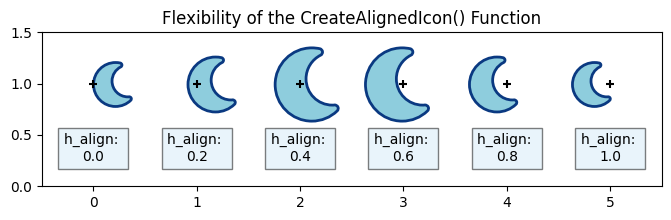

In [114]:
# List of horizontal and vertical alignments to test
icon_valign =  0.5
icon_halign = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# Specify size and color for the icons
marker_size = 3000
icon_faceCol = '#8ECDDD'
icon_edgeCol = '#0A3981'
edge_width = 2

# Generate a figure
plt.figure(figsize=(8, 2))

# Generate the stars with the plt.scatter function
for i in range(0, len(icon_halign)):
	# Generate the icon with the CreateAlignedIcon function and plot it with plt.scatter
	icon_path = CreateAlignedIcon(fa_dict["moon"], fp_solid, icon_halign[i], icon_valign)

	# Scatter plot of the icon and a '+' to mark the spot
	plt.scatter(i, 1, color=icon_faceCol, marker=icon_path, s=marker_size, edgecolor=icon_edgeCol, linewidth=edge_width)
	plt.scatter(i, 1, color='black', marker='+')
	
	# Description
	plt.text(i, 0.25, f"h_align: \n{icon_halign[i]}", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5), ha='center')

# Plot logistics
plt.title("Flexibility of the CreateAlignedIcon() Function")
plt.xlim(-0.5, len(icon_halign) - 0.5)
plt.ylim(0, 1.5)
plt.show()

The `CreateAlignedIcon()` function can manage small modifications in the horizontal and vertical icon alignments. This feature was not available when plotting the icons as text objects. 

We do need to keep in mind that the icon sizes do seem to vary depending on the location of the horizontal and vertical alignment coordinates. For now, we can adjust this with the marker size when calling the `plt.scatter()` function.

Refer to the [official `matplotlib` documentation on `plt.scatter()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) for more information. 

We are now able to plot Font Awesome icons in `matplot.pyplot()` as text or path objects with user's designated coordinates, icon size, icon color and rotation. We can adjust the icon's horizontal and vertical alignments, and even change the icon edge color when using the `plt.scatter()` function. 

So what now? 

I'll show you one extra trick which allows you to draw part of an icon. 

When plotting Font Awesome icons as markers in a scatter plot, horizontal and vertical alignments were set in the generation of the path. While it does require some computing to get the exact desired coordinates, the `CreateAlignedIcon()` function created allows icons to be aligned in ways that were not possible as text objects. 

In a similar manner, when we'd like the icons to be rotated in the scatter plots, we must rotate them during path generation. 


Another feature of paths is in the precise assignment of offsets in its creation. These affect the horizontal and vertical alignment of the icons relative to the coordinates specified in `plt.scatter()`.

On the other hand, there are several features the icons can now do with the `plt.scatter()` function. Let's explore a couple of the options 



- My own function
- vertical and horizontal alignment
- show left half, right half, top half, bottom half

### Plotting Part of an Icon 

Using bbox to show only part of an icon. 

In [278]:
def CreatePartialIcon(icon_unicode, icon_font_prop, h_align, v_align, h_frac, v_frac):
    """Function to generate a path from the icon unicode with specified horizontal and vertical alignments. Requires matplotlib.path.Path, matplotlib.text.TextPath and numpy to be imported.
    AUTHOR:     Mai Tanaka (www.DataDrivenMai.com)
    DATE:       2026-05-11
    REQUIRES:   icon_unicode = unicode for the icon (eg. '\uf005' for the star icon in Font Awesome)
                icon_font_prop = matplotlib.font_manager.FontProperties object for the icon 
                h_align = horizontal alignment (0 = left, 0.5 = center, 1 = right)
                v_align = vertical alignment (0 = bottom, 0.5 = center, 1 = top)
                
    RETURNS:    final_path = a matplotlib.path.Path object with the specified alignments
    """
    
	# Constants
    path_size = 100 # Arbitrary path size that is easy to work with
    
	# Create the initial TextPath to check its max and min values
    test_path = TextPath((0, 0), icon_unicode, prop=icon_font_prop, size=path_size)

	# Extract the vertices and codes from the test_path
    test_vertices = test_path.vertices
    test_codes = test_path.codes

	# Calculate the max and min coordinates of the icon path
    max_x, max_y = test_path.vertices.max(axis=0)
    min_x, min_y = test_path.vertices.min(axis=0)

	# Calculate the correctional offset required to obtain the desired alignment
    offset_x = (max_x - min_x) * h_align
    offset_y = (max_y - min_y) * v_align

	# Calculate the new vertices by applying the offsets
    new_vertices = np.zeros_like(test_vertices)
    new_vertices[:, 0] = test_vertices[:, 0] - min_x - offset_x
    new_vertices[:, 1] = test_vertices[:, 1] - min_y - offset_y
    
	# Apply the fractional limit
    print(h_frac[0])
    limits_x = [0, 0]
    limits_y = [0, 0]
    limits_x[0] = (max_x - min_x) * h_frac[0] - min_x - offset_x
    limits_x[1] = (max_x - min_x) * h_frac[1] - min_x - offset_x
    limits_y[0] = (max_y - min_y) * v_frac[0] - min_y - offset_y
    limits_y[1] = (max_y - min_y) * v_frac[1] - min_y - offset_y
    
	# Apply a floor and ceiling value
    xmin_boolMask = new_vertices[:, 0] < limits_x[0]
    new_vertices[xmin_boolMask, 0] = limits_x[0]
    xmax_boolMask = new_vertices[:, 0] > limits_x[1]
    new_vertices[xmax_boolMask, 0] = limits_x[1]
    ymin_boolMask = new_vertices[:, 1] < limits_y[0]
    new_vertices[ymin_boolMask, 1] = limits_y[0]
    ymax_boolMask = new_vertices[:, 1] > limits_y[1]
    new_vertices[ymax_boolMask, 1] = limits_y[1]
    
	# Create the final path with the new vertices and original code
    final_path = Path(new_vertices, test_codes)

	# Return English wind direction
    return final_path

0.0
0.2
0.3
0.4
0.5


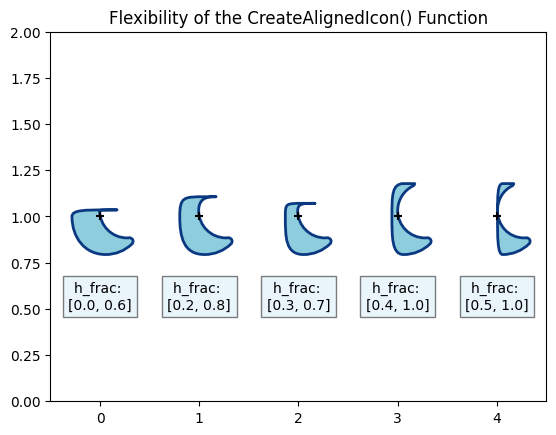

In [276]:
# Horizontal and vertical fractions
icon_hfrac = [[0.0, 0.6], [0.2, 0.8], [0.3, 0.7], [0.4, 1.0], [0.5, 1.0]]
icon_vfrac = [0, 1.0]

# Specify size and color for the icons
marker_size = 3000
icon_faceCol = '#8ECDDD'
icon_edgeCol = '#0A3981'
edge_width = 2
icon_valign =  0.5
icon_halign = 0.5

# Generate a figure
plt.figure()

# Generate the stars with the plt.scatter function
for i in range(0, len(icon_hfrac)):
	# Generate the icon with the CreateAlignedIcon function and plot it with plt.scatter
	icon_path = CreatePartialIcon(fa_dict["moon"], fp_solid, icon_halign, icon_valign, icon_hfrac[i], icon_vfrac)

	# Scatter plot of the icon and a '+' to mark the spot
	plt.scatter(i, 1, color=icon_faceCol, marker=icon_path, s=marker_size, edgecolor=icon_edgeCol, linewidth=edge_width)
	plt.scatter(i, 1, color='black', marker='+')
	
	# Description
	plt.text(i, 0.5, f"h_frac: \n{icon_hfrac[i]}", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5), ha='center')

# Plot logistics
plt.title("Flexibility of the CreateAlignedIcon() Function")
plt.xlim(-0.5, len(icon_hfrac) - 0.5)
plt.ylim(0, 2)
plt.show()

In [ ]:
font_path = "C:/Users/jagar/Documents_Local/data/fontawesome-free-7.2.0-desktop/otfs/Font Awesome 7 Free-Solid-900.otf"
fp = FontProperties(fname=font_path)

font_path = "C:/Users/jagar/Documents_Local/data/fontawesome-free-7.2.0-desktop/otfs/Font Awesome 7 Free-Regular-400.otf"
fp2 = FontProperties(fname=font_path)

plt.figure(figsize=(6, 4))

# Use the unicode for 'coffee' (\uf0f4)
plt.text(0.5, 0.5, '\uf21a', fontproperties=fp, color='#22668D', fontsize=50, ha='center', va='center', rotation=45)
#plt.text(0.25, 0.5, '\uf21a', fontproperties=fp, fontsize=50, ha='left', va='baseline')
#plt.text(0.75, 0.5, '\uf21a', fontproperties=fp, fontsize=25, ha='left', va='bottom')

text_path = TextPath((-120, -120), '\uf21a', prop=fp, size=300)
#p1 = PathPatch(text_path, ec="w", lw=3, fc="w", alpha=0.9)

print(type(text_path))
#print(type(p1))

# Scatter plot
plt.scatter([0.25, 0.5, 0.75], [0.5, 0.5, 0.5], color='red', marker=text_path, s= 10000, edgecolors='green')

plt.title("Font Awesome in Matplotlib", fontsize=14)
plt.show()


### Bar Graph with Icons

- My own function to make horizontal or vertical bar graph 
	- Possible to move this bit into the blog post explaining the Pydy Tuesday 2026-05-05 on ships
	- Assume the icon is the same within the bar
- Stacked bar graph also possible (for another day?)

## Differences Between Text and Path

- Manual editing of shapes
- Fontsize vs marker size
- Outside the axis or cut off at axis
- Marker edge color
- Image clipping

## Fun plot of Starry Night	

### Image Overlay Method

## Summary